<a href="https://colab.research.google.com/github/kanchandhole/Data-Scientist/blob/main/06April_Support_Vector_Machines_1_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Data Science Masters

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import seaborn as sns
from sklearn import datasets
from sklearn.svm import SVC, LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Plotting style
plt.rcParams['figure.facecolor'] = '#0d1117'
plt.rcParams['axes.facecolor'] = '#161b22'
plt.rcParams['axes.edgecolor'] = '#30363d'
plt.rcParams['text.color'] = '#e6edf3'
plt.rcParams['axes.labelcolor'] = '#e6edf3'
plt.rcParams['xtick.color'] = '#8b949e'
plt.rcParams['ytick.color'] = '#8b949e'
plt.rcParams['grid.color'] = '#21262d'
plt.rcParams['grid.linewidth'] = 0.8
plt.rcParams['font.family'] = 'monospace'
plt.rcParams['axes.titlecolor'] = '#58a6ff'

COLORS = ['#58a6ff', '#f78166', '#3fb950', '#e3b341', '#bc8cff']
print('✅ All libraries loaded successfully!')

✅ All libraries loaded successfully!


---
## Q1. Mathematical Formula for a Linear SVM
---

### 📐 Linear SVM – Core Mathematics

A **linear SVM** finds a hyperplane that best separates two classes in an $n$-dimensional feature space.

---

#### 1. Decision Hyperplane

$$\mathbf{w}^T \mathbf{x} + b = 0$$

Where:
- $\mathbf{w} \in \mathbb{R}^n$ — weight vector (normal to the hyperplane)
- $\mathbf{x} \in \mathbb{R}^n$ — input feature vector
- $b \in \mathbb{R}$ — bias term (shifts the hyperplane)

---

#### 2. Decision Function

For a new data point $\mathbf{x}$, the predicted class label is:

$$\hat{y} = \text{sign}(\mathbf{w}^T \mathbf{x} + b)$$

- If $\mathbf{w}^T \mathbf{x} + b > 0 \Rightarrow \hat{y} = +1$ (Class +1)
- If $\mathbf{w}^T \mathbf{x} + b < 0 \Rightarrow \hat{y} = -1$ (Class −1)

---

#### 3. Margin Width Formula

The geometric margin (distance between the two marginal hyperplanes) is:

$$\text{Margin} = \frac{2}{\|\mathbf{w}\|}$$

SVM **maximises** this margin.

---

#### 4. Functional Margin Constraints

For correctly classified training points $(\mathbf{x}_i, y_i)$ where $y_i \in \{-1, +1\}$:

$$y_i (\mathbf{w}^T \mathbf{x}_i + b) \geq 1 \quad \forall i$$

The two marginal hyperplanes:
- Positive margin: $\mathbf{w}^T \mathbf{x} + b = +1$
- Negative margin: $\mathbf{w}^T \mathbf{x} + b = -1$

---

#### 5. Distance from Point to Hyperplane

The perpendicular distance from point $\mathbf{x}_i$ to the hyperplane $\mathbf{w}^T \mathbf{x} + b = 0$:

$$d_i = \frac{y_i(\mathbf{w}^T \mathbf{x}_i + b)}{\|\mathbf{w}\|}$$

---
## Q2. Objective Function of a Linear SVM
---

### 🎯 SVM Objective Function

---

#### Hard-Margin SVM (Linearly Separable Data)

**Primal Formulation** – Minimise $\mathbf{w}$ subject to constraints:

$$\min_{\mathbf{w}, b} \quad \frac{1}{2} \|\mathbf{w}\|^2$$
$$\text{subject to:} \quad y_i(\mathbf{w}^T \mathbf{x}_i + b) \geq 1 \quad \forall i = 1, \ldots, N$$

Minimising $\|\mathbf{w}\|^2$ is equivalent to **maximising the margin** $\frac{2}{\|\mathbf{w}\|}$.

---

#### Soft-Margin SVM (Non-Separable Data)

Introduces slack variables $\xi_i \geq 0$ to allow misclassifications:

$$\min_{\mathbf{w}, b, \boldsymbol{\xi}} \quad \frac{1}{2}\|\mathbf{w}\|^2 + C \sum_{i=1}^{N} \xi_i$$

$$\text{subject to:} \quad y_i(\mathbf{w}^T \mathbf{x}_i + b) \geq 1 - \xi_i, \quad \xi_i \geq 0 \quad \forall i$$

Where:
- $C > 0$ — **regularisation parameter** (controls the bias-variance tradeoff)
- $\xi_i$ — **slack variable** for data point $i$ (how much it violates the margin)

| $C$ value | Effect |
|-----------|--------|
| Large $C$ | Small margin, fewer misclassifications (low bias, high variance) |
| Small $C$ | Large margin, more misclassifications allowed (high bias, low variance) |

---

#### Dual Formulation (via Lagrangian)

Using Lagrange multipliers $\alpha_i \geq 0$, the dual objective is:

$$\max_{\boldsymbol{\alpha}} \quad \sum_{i=1}^{N} \alpha_i - \frac{1}{2} \sum_{i=1}^{N} \sum_{j=1}^{N} \alpha_i \alpha_j y_i y_j \mathbf{x}_i^T \mathbf{x}_j$$

$$\text{subject to:} \quad \sum_{i=1}^{N} \alpha_i y_i = 0, \quad 0 \leq \alpha_i \leq C$$

KKT Conditions give:
$$\mathbf{w} = \sum_{i=1}^{N} \alpha_i y_i \mathbf{x}_i$$

Only support vectors (where $\alpha_i > 0$) contribute to $\mathbf{w}$.

---
## Q3. The Kernel Trick in SVM
---

### 🔮 The Kernel Trick

---

#### Why Kernels?

Many real-world datasets are **not linearly separable** in the original feature space. The kernel trick allows SVM to operate in a **higher-dimensional space implicitly** — without explicitly computing the transformation.

#### Key Insight

The dual objective contains only **dot products** $\mathbf{x}_i^T \mathbf{x}_j$. We can replace these with a **kernel function**:

$$K(\mathbf{x}_i, \mathbf{x}_j) = \phi(\mathbf{x}_i)^T \phi(\mathbf{x}_j)$$

Where $\phi: \mathbb{R}^n \rightarrow \mathbb{R}^m$ maps to a higher-dimensional space.

The dual becomes:

$$\max_{\boldsymbol{\alpha}} \sum_{i=1}^{N} \alpha_i - \frac{1}{2} \sum_{i,j} \alpha_i \alpha_j y_i y_j K(\mathbf{x}_i, \mathbf{x}_j)$$

---

#### Common Kernel Functions

| Kernel | Formula | Use Case |
|--------|---------|----------|
| **Linear** | $K(\mathbf{x}_i, \mathbf{x}_j) = \mathbf{x}_i^T \mathbf{x}_j$ | Linearly separable data |
| **Polynomial** | $K(\mathbf{x}_i, \mathbf{x}_j) = (\gamma\, \mathbf{x}_i^T \mathbf{x}_j + r)^d$ | Polynomial decision boundaries |
| **RBF / Gaussian** | $K(\mathbf{x}_i, \mathbf{x}_j) = \exp\left(-\gamma \|\mathbf{x}_i - \mathbf{x}_j\|^2\right)$ | Non-linear, general purpose |
| **Sigmoid** | $K(\mathbf{x}_i, \mathbf{x}_j) = \tanh(\gamma\, \mathbf{x}_i^T \mathbf{x}_j + r)$ | Neural network-like |

---

#### Example: XOR Problem

Points $(0,0), (1,1)$ → Class 0; Points $(0,1), (1,0)$ → Class 1  
XOR is **not linearly separable** in 2D. With an RBF kernel, SVM can classify it perfectly by operating in infinite-dimensional feature space.

#### Mercer's Theorem
A function $K$ is a valid kernel if and only if the kernel matrix (Gram matrix) is **positive semi-definite** for any set of inputs.

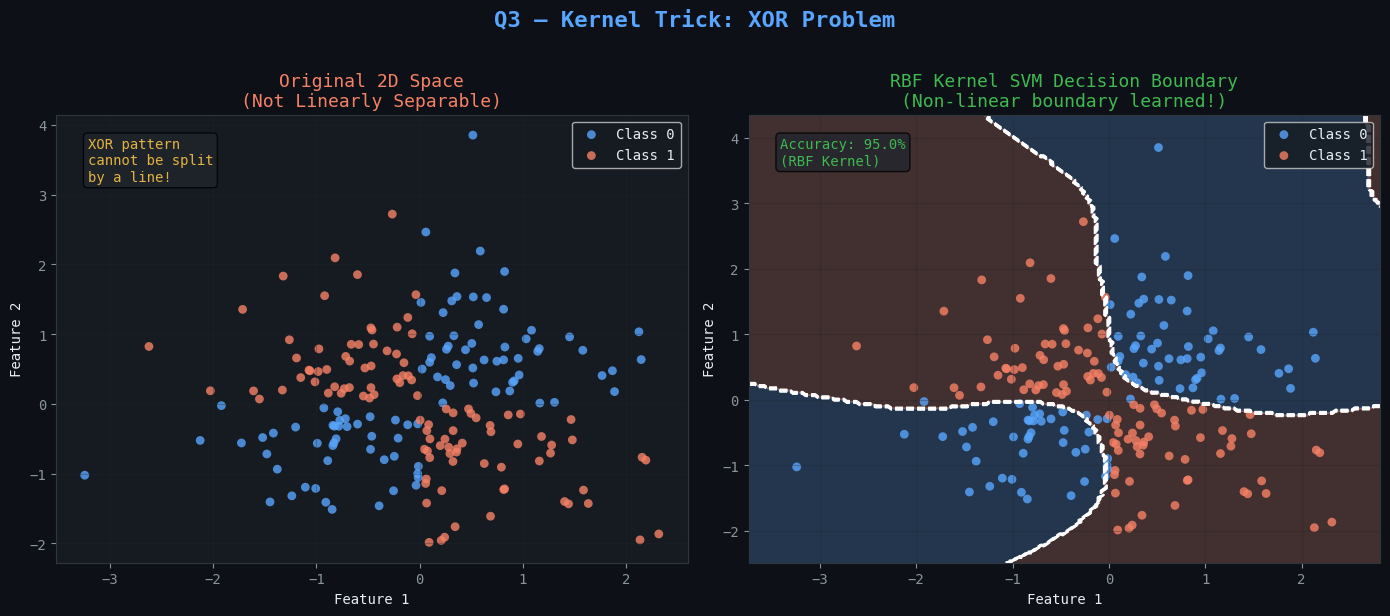

✅ Q3 Kernel trick visualised!


In [2]:
# Q3: Visual – Kernel Trick (XOR not separable → separable)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Q3 – Kernel Trick: XOR Problem', fontsize=16, color='#58a6ff', fontweight='bold', y=1.02)

np.random.seed(42)
X_xor = np.random.randn(200, 2)
y_xor = np.logical_xor(X_xor[:, 0] > 0, X_xor[:, 1] > 0).astype(int)

# Left: Original 2D space (not linearly separable)
ax = axes[0]
colors = [COLORS[0], COLORS[1]]
for cls, col, label in zip([0, 1], colors, ['Class 0', 'Class 1']):
    mask = y_xor == cls
    ax.scatter(X_xor[mask, 0], X_xor[mask, 1], c=col, label=label, s=40, alpha=0.8, edgecolors='none')
ax.set_title('Original 2D Space\n(Not Linearly Separable)', fontsize=13, color='#f78166')
ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2')
ax.legend()
ax.grid(True, alpha=0.3)
ax.text(0.05, 0.95, 'XOR pattern\ncannot be split\nby a line!',
        transform=ax.transAxes, va='top', color='#e3b341',
        fontsize=10, bbox=dict(boxstyle='round', facecolor='#21262d', alpha=0.8))

# Right: With RBF Kernel SVM decision boundary
ax = axes[1]
svm_rbf = SVC(kernel='rbf', C=1.0, gamma=1.0)
svm_rbf.fit(X_xor, y_xor)

xx, yy = np.meshgrid(np.linspace(X_xor[:,0].min()-0.5, X_xor[:,0].max()+0.5, 200),
                     np.linspace(X_xor[:,1].min()-0.5, X_xor[:,1].max()+0.5, 200))
Z = svm_rbf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
ax.contourf(xx, yy, Z, alpha=0.2, cmap=ListedColormap(['#58a6ff', '#f78166']))
ax.contour(xx, yy, Z, colors='white', linewidths=1.5, linestyles='--')
for cls, col, label in zip([0, 1], colors, ['Class 0', 'Class 1']):
    mask = y_xor == cls
    ax.scatter(X_xor[mask, 0], X_xor[mask, 1], c=col, label=label, s=40, alpha=0.8, edgecolors='none')
ax.set_title('RBF Kernel SVM Decision Boundary\n(Non-linear boundary learned!)', fontsize=13, color='#3fb950')
ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2')
ax.legend()
ax.grid(True, alpha=0.3)
acc = accuracy_score(y_xor, svm_rbf.predict(X_xor))
ax.text(0.05, 0.95, f'Accuracy: {acc:.1%}\n(RBF Kernel)',
        transform=ax.transAxes, va='top', color='#3fb950',
        fontsize=10, bbox=dict(boxstyle='round', facecolor='#21262d', alpha=0.8))

plt.tight_layout()
plt.savefig('q3_kernel_trick.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('✅ Q3 Kernel trick visualised!')

---
## Q4. Role of Support Vectors in SVM
---

### 🏋️ Support Vectors – Definition & Role

---

**Support Vectors** are the training data points that lie **exactly on the marginal hyperplanes** (or within the margin for soft-margin SVM). They are the **critical data points** that define the position and orientation of the decision hyperplane.

#### Mathematical Definition

Support vectors are data points where the **KKT constraint is active**, i.e., where the Lagrange multiplier $\alpha_i > 0$:

$$y_i(\mathbf{w}^T \mathbf{x}_i + b) = 1 \quad \Leftrightarrow \quad \alpha_i > 0$$

The weight vector is computed **only from support vectors**:

$$\mathbf{w} = \sum_{i \in \text{SVs}} \alpha_i y_i \mathbf{x}_i$$

#### Key Roles of Support Vectors

| Role | Description |
|------|-------------|
| **Define the margin** | SVs lie on the marginal planes; the margin width is $\frac{2}{\|w\|}$ |
| **Determine the boundary** | Removing non-SVs does not change the hyperplane |
| **Model sparsity** | Only SVs have $\alpha_i > 0$; other points have $\alpha_i = 0$ |
| **Enable kernelisation** | Prediction uses $K(\mathbf{x}_{SV}, \mathbf{x}_{test})$ only for SVs |

#### Example

Suppose we have 1000 training points but only 5 are support vectors. The SVM model is **fully described by those 5 points**. Moving any other 995 points (as long as they don't cross the margin) does not change the classifier at all!

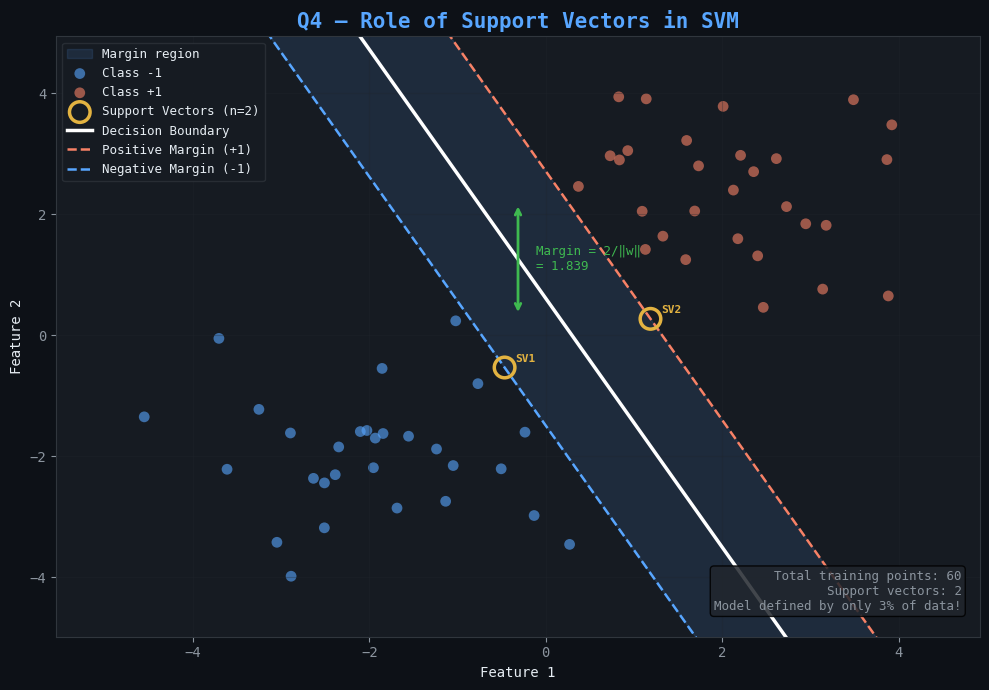

✅ Support vectors identified: 2 out of 60 points


In [3]:
# Q4: Visual – Support Vectors highlighted
np.random.seed(0)
X_sv = np.r_[np.random.randn(30, 2) - [2, 2], np.random.randn(30, 2) + [2, 2]]
y_sv = np.array([-1]*30 + [1]*30)

clf = SVC(kernel='linear', C=1.0)
clf.fit(X_sv, y_sv)

fig, ax = plt.subplots(figsize=(10, 7))

# Decision boundary and margins
xlim = [X_sv[:,0].min()-1, X_sv[:,0].max()+1]
ylim = [X_sv[:,1].min()-1, X_sv[:,1].max()+1]
xx = np.linspace(xlim[0], xlim[1], 300)
w = clf.coef_[0]; b = clf.intercept_[0]

# Hyperplane: w[0]*x + w[1]*y + b = 0 => y = -(w[0]*x+b)/w[1]
yy_hyp  = -(w[0]*xx + b) / w[1]
yy_pos  = -(w[0]*xx + b - 1) / w[1]
yy_neg  = -(w[0]*xx + b + 1) / w[1]

# Margin shading
ax.fill_between(xx, yy_neg, yy_pos, alpha=0.12, color='#58a6ff', label='Margin region')

# Scatter non-SVs
sv_idx = clf.support_
non_sv_mask = np.ones(len(X_sv), dtype=bool)
non_sv_mask[sv_idx] = False

ax.scatter(X_sv[non_sv_mask & (y_sv == -1), 0], X_sv[non_sv_mask & (y_sv == -1), 1],
           c=COLORS[0], s=60, alpha=0.6, label='Class -1', edgecolors='none')
ax.scatter(X_sv[non_sv_mask & (y_sv == 1), 0], X_sv[non_sv_mask & (y_sv == 1), 1],
           c=COLORS[1], s=60, alpha=0.6, label='Class +1', edgecolors='none')

# Support vectors highlighted
ax.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
           s=220, linewidths=2.5, facecolors='none', edgecolors='#e3b341',
           zorder=5, label=f'Support Vectors (n={len(sv_idx)})')

# Draw margin lines
ax.plot(xx, yy_hyp, '-', color='white', lw=2.5, label='Decision Boundary')
ax.plot(xx, yy_pos, '--', color=COLORS[1], lw=1.8, label='Positive Margin (+1)')
ax.plot(xx, yy_neg, '--', color=COLORS[0], lw=1.8, label='Negative Margin (-1)')

# Annotate support vectors
for i, sv in enumerate(clf.support_vectors_):
    ax.annotate(f'SV{i+1}', sv, textcoords='offset points', xytext=(8, 4),
                fontsize=8, color='#e3b341', fontweight='bold')

# Margin width arrow
margin = 2 / np.linalg.norm(w)
mid_x = (xlim[0] + xlim[1]) / 2
mid_y_hyp = -(w[0]*mid_x + b) / w[1]
ax.annotate('', xy=(mid_x, mid_y_hyp + margin/2), xytext=(mid_x, mid_y_hyp - margin/2),
            arrowprops=dict(arrowstyle='<->', color='#3fb950', lw=2))
ax.text(mid_x + 0.2, mid_y_hyp, f'Margin = 2/‖w‖\n= {margin:.3f}',
        color='#3fb950', fontsize=9, va='center')

ax.set_xlim(xlim); ax.set_ylim(ylim)
ax.set_title('Q4 – Role of Support Vectors in SVM', fontsize=15, color='#58a6ff', fontweight='bold')
ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2')
ax.legend(loc='upper left', fontsize=9, framealpha=0.7,
          facecolor='#161b22', edgecolor='#30363d')
ax.grid(True, alpha=0.3)

# Info box
info = (f'Total training points: {len(X_sv)}\n'
        f'Support vectors: {len(sv_idx)}\n'
        f'Model defined by only {len(sv_idx)/len(X_sv)*100:.0f}% of data!')
ax.text(0.98, 0.04, info, transform=ax.transAxes, ha='right', va='bottom',
        color='#8b949e', fontsize=9, bbox=dict(boxstyle='round', facecolor='#21262d', alpha=0.85))

plt.tight_layout()
plt.savefig('q4_support_vectors.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(f'✅ Support vectors identified: {len(sv_idx)} out of {len(X_sv)} points')

---
## Q5. Hyperplane, Marginal Plane, Soft Margin & Hard Margin
---

### 📊 Key SVM Concepts

| Concept | Definition | Equation |
|---------|-----------|----------|
| **Hyperplane** | The decision boundary separating two classes | $\mathbf{w}^T\mathbf{x} + b = 0$ |
| **Positive Marginal Plane** | Boundary on the positive class side | $\mathbf{w}^T\mathbf{x} + b = +1$ |
| **Negative Marginal Plane** | Boundary on the negative class side | $\mathbf{w}^T\mathbf{x} + b = -1$ |
| **Hard Margin** | No violations allowed; only for linearly separable data | $y_i(\mathbf{w}^T\mathbf{x}_i + b) \geq 1$ |
| **Soft Margin** | Violations allowed via slack $\xi_i$; for noisy/overlapping data | $y_i(\mathbf{w}^T\mathbf{x}_i + b) \geq 1 - \xi_i$ |

**Slack variable interpretation:**
- $\xi_i = 0$: Point on or outside margin (correct)
- $0 < \xi_i \leq 1$: Inside margin but correctly classified
- $\xi_i > 1$: Misclassified point

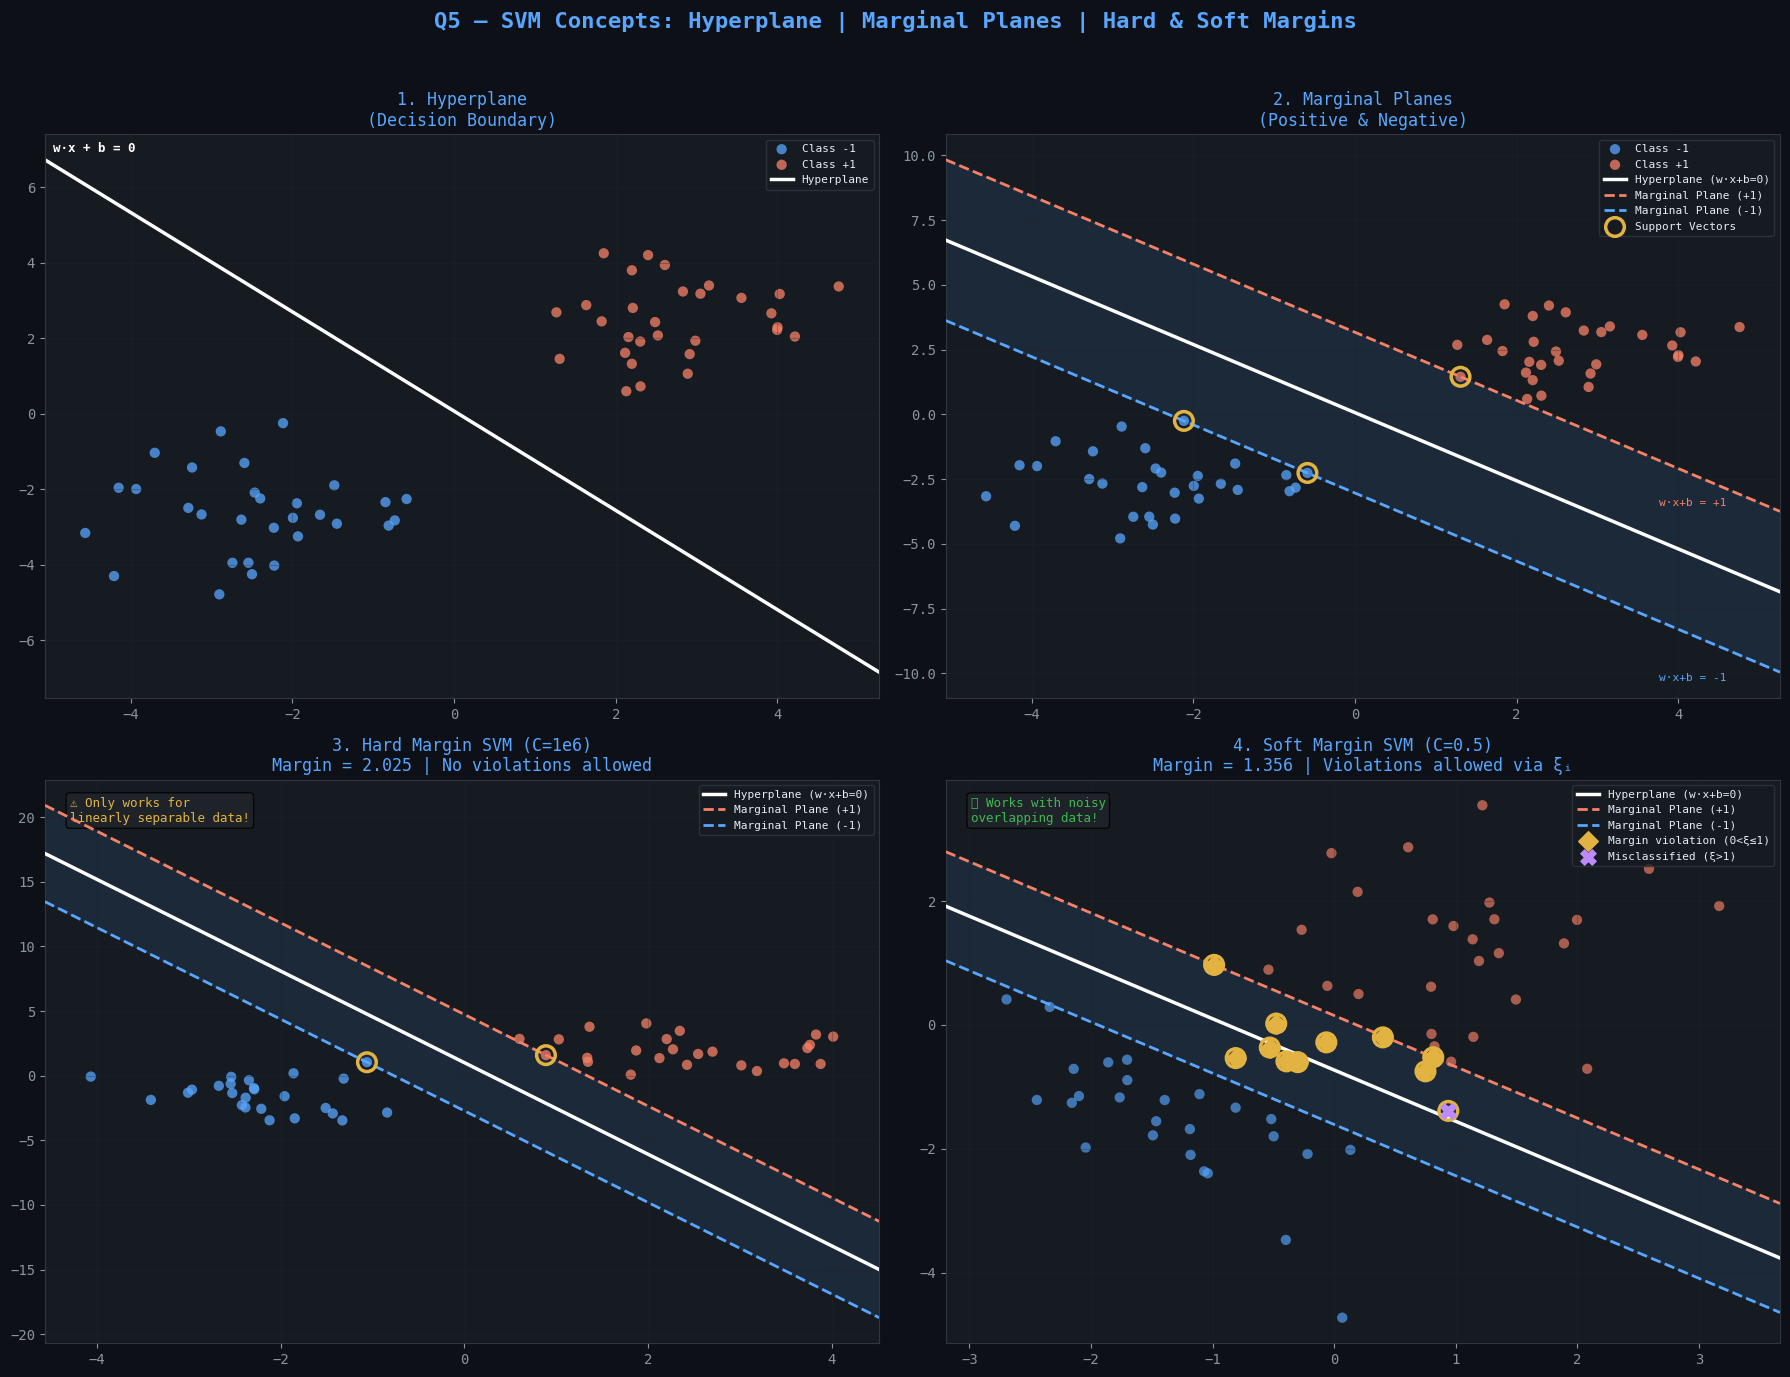

✅ Q5 visualisation complete!


In [4]:
# Q5: Comprehensive Visual – 4 subplots
fig = plt.figure(figsize=(18, 14))
fig.patch.set_facecolor('#0d1117')
fig.suptitle('Q5 – SVM Concepts: Hyperplane | Marginal Planes | Hard & Soft Margins',
             fontsize=16, color='#58a6ff', fontweight='bold', y=0.98)

np.random.seed(7)

# ── Helper: draw hyperplane & margins ──────────────────────
def draw_svm_lines(ax, clf, xlim):
    xx = np.linspace(xlim[0], xlim[1], 300)
    w = clf.coef_[0]; b = clf.intercept_[0]
    yy_h = -(w[0]*xx + b) / w[1]
    yy_p = -(w[0]*xx + b - 1) / w[1]
    yy_n = -(w[0]*xx + b + 1) / w[1]
    margin = 2 / np.linalg.norm(w)
    ax.fill_between(xx, yy_n, yy_p, alpha=0.1, color='#58a6ff')
    ax.plot(xx, yy_h, '-', color='white', lw=2.5, label='Hyperplane (w·x+b=0)', zorder=4)
    ax.plot(xx, yy_p, '--', color=COLORS[1], lw=2, label='Marginal Plane (+1)', zorder=4)
    ax.plot(xx, yy_n, '--', color=COLORS[0], lw=2, label='Marginal Plane (-1)', zorder=4)
    return margin

# ─── PLOT 1: Hyperplane ────────────────────────────────────
ax1 = fig.add_subplot(2, 2, 1)
X_h = np.r_[np.random.randn(30, 2) - [2.5, 2.5], np.random.randn(30, 2) + [2.5, 2.5]]
y_h = np.array([-1]*30 + [1]*30)
clf_h = SVC(kernel='linear', C=100); clf_h.fit(X_h, y_h)
xlim_h = [X_h[:,0].min()-0.5, X_h[:,0].max()+0.5]
xx_h = np.linspace(xlim_h[0], xlim_h[1], 300)
w_h = clf_h.coef_[0]; b_h = clf_h.intercept_[0]
yy_hh = -(w_h[0]*xx_h + b_h) / w_h[1]
ax1.scatter(X_h[y_h==-1,0], X_h[y_h==-1,1], c=COLORS[0], s=55, alpha=0.75, label='Class -1', edgecolors='none')
ax1.scatter(X_h[y_h==1,0], X_h[y_h==1,1], c=COLORS[1], s=55, alpha=0.75, label='Class +1', edgecolors='none')
ax1.plot(xx_h, yy_hh, '-', color='white', lw=2.5, label='Hyperplane')
ax1.text(xlim_h[0]+0.1, yy_hh[0]+0.2, 'w·x + b = 0', color='white', fontsize=9, fontweight='bold')
ax1.set_title('1. Hyperplane\n(Decision Boundary)', fontsize=12, color='#58a6ff')
ax1.legend(fontsize=8, facecolor='#161b22', edgecolor='#30363d')
ax1.grid(True, alpha=0.3); ax1.set_facecolor('#161b22')
ax1.set_xlim(xlim_h)

# ─── PLOT 2: Marginal Planes ───────────────────────────────
ax2 = fig.add_subplot(2, 2, 2)
ax2.scatter(X_h[y_h==-1,0], X_h[y_h==-1,1], c=COLORS[0], s=55, alpha=0.75, label='Class -1', edgecolors='none')
ax2.scatter(X_h[y_h==1,0], X_h[y_h==1,1], c=COLORS[1], s=55, alpha=0.75, label='Class +1', edgecolors='none')
margin_h = draw_svm_lines(ax2, clf_h, xlim_h)
ax2.scatter(clf_h.support_vectors_[:,0], clf_h.support_vectors_[:,1],
            s=180, facecolors='none', edgecolors='#e3b341', lw=2.5, zorder=6, label='Support Vectors')
xx_m = np.linspace(xlim_h[0], xlim_h[1], 300)
yy_pos_m = -(w_h[0]*xx_m + b_h - 1) / w_h[1]
yy_neg_m = -(w_h[0]*xx_m + b_h + 1) / w_h[1]
ax2.text(xlim_h[1]-1.5, yy_pos_m[-1]+0.2, 'w·x+b = +1', color=COLORS[1], fontsize=8)
ax2.text(xlim_h[1]-1.5, yy_neg_m[-1]-0.35, 'w·x+b = -1', color=COLORS[0], fontsize=8)
ax2.set_title('2. Marginal Planes\n(Positive & Negative)', fontsize=12, color='#58a6ff')
ax2.legend(fontsize=8, facecolor='#161b22', edgecolor='#30363d')
ax2.grid(True, alpha=0.3); ax2.set_facecolor('#161b22')
ax2.set_xlim(xlim_h)

# ─── PLOT 3: Hard Margin ──────────────────────────────────
ax3 = fig.add_subplot(2, 2, 3)
X_hard = np.r_[np.random.randn(25,2)-[2,2], np.random.randn(25,2)+[2,2]]
y_hard = np.array([-1]*25 + [1]*25)
clf_hard = SVC(kernel='linear', C=1e6); clf_hard.fit(X_hard, y_hard)
xlim_hd = [X_hard[:,0].min()-0.5, X_hard[:,0].max()+0.5]
margin_hard = draw_svm_lines(ax3, clf_hard, xlim_hd)
ax3.scatter(X_hard[y_hard==-1,0], X_hard[y_hard==-1,1], c=COLORS[0], s=55, alpha=0.75, edgecolors='none')
ax3.scatter(X_hard[y_hard==1,0], X_hard[y_hard==1,1], c=COLORS[1], s=55, alpha=0.75, edgecolors='none')
ax3.scatter(clf_hard.support_vectors_[:,0], clf_hard.support_vectors_[:,1],
            s=180, facecolors='none', edgecolors='#e3b341', lw=2.5, zorder=6)
ax3.set_title(f'3. Hard Margin SVM (C=1e6)\nMargin = {margin_hard:.3f} | No violations allowed',
              fontsize=12, color='#58a6ff')
ax3.text(0.03, 0.97, '⚠ Only works for\nlinearly separable data!',
         transform=ax3.transAxes, va='top', color='#e3b341', fontsize=9,
         bbox=dict(boxstyle='round', facecolor='#21262d', alpha=0.8))
ax3.legend(fontsize=8, facecolor='#161b22', edgecolor='#30363d')
ax3.grid(True, alpha=0.3); ax3.set_facecolor('#161b22')
ax3.set_xlim(xlim_hd)

# ─── PLOT 4: Soft Margin ──────────────────────────────────
ax4 = fig.add_subplot(2, 2, 4)
X_soft = np.r_[np.random.randn(30,2)-[1.2,1.2], np.random.randn(30,2)+[1.2,1.2]]
y_soft = np.array([-1]*30 + [1]*30)
# Add noisy / overlapping points
X_soft = np.vstack([X_soft, [[0.2,0.5],[-0.3,-0.6],[0.4,-0.2]]])
y_soft = np.hstack([y_soft, [1, -1, 1]])

clf_soft = SVC(kernel='linear', C=0.5); clf_soft.fit(X_soft, y_soft)
xlim_sf = [X_soft[:,0].min()-0.5, X_soft[:,0].max()+0.5]
margin_soft = draw_svm_lines(ax4, clf_soft, xlim_sf)

# Color misclassified / margin violators differently
scores = y_soft * (X_soft @ clf_soft.coef_[0] + clf_soft.intercept_[0])
in_margin = (scores < 1) & (scores > 0)
misclassified = scores <= 0

ax4.scatter(X_soft[y_soft==-1,0], X_soft[y_soft==-1,1], c=COLORS[0], s=55, alpha=0.65, edgecolors='none')
ax4.scatter(X_soft[y_soft==1,0], X_soft[y_soft==1,1], c=COLORS[1], s=55, alpha=0.65, edgecolors='none')
# Highlight violators
if in_margin.any():
    ax4.scatter(X_soft[in_margin,0], X_soft[in_margin,1], c='#e3b341', s=100,
                marker='D', zorder=6, label='Margin violation (0<ξ≤1)')
if misclassified.any():
    ax4.scatter(X_soft[misclassified,0], X_soft[misclassified,1], c='#bc8cff', s=120,
                marker='X', zorder=6, label='Misclassified (ξ>1)')
ax4.scatter(clf_soft.support_vectors_[:,0], clf_soft.support_vectors_[:,1],
            s=180, facecolors='none', edgecolors='#e3b341', lw=2.5, zorder=5)
ax4.set_title(f'4. Soft Margin SVM (C=0.5)\nMargin = {margin_soft:.3f} | Violations allowed via ξᵢ',
              fontsize=12, color='#58a6ff')
ax4.text(0.03, 0.97, '✅ Works with noisy\noverlapping data!',
         transform=ax4.transAxes, va='top', color='#3fb950', fontsize=9,
         bbox=dict(boxstyle='round', facecolor='#21262d', alpha=0.8))
ax4.legend(fontsize=8, facecolor='#161b22', edgecolor='#30363d')
ax4.grid(True, alpha=0.3); ax4.set_facecolor('#161b22')
ax4.set_xlim(xlim_sf)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('q5_svm_concepts.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('✅ Q5 visualisation complete!')

---
## Q6. SVM Implementation on the Iris Dataset
---

In [5]:
# Q6: Load & Explore Iris Dataset
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

iris = load_iris()
X, y = iris.data, iris.target
feature_names = iris.feature_names
target_names = iris.target_names

print('=' * 55)
print('         IRIS DATASET OVERVIEW')
print('=' * 55)
print(f'  Features  : {feature_names}')
print(f'  Classes   : {list(target_names)}')
print(f'  Samples   : {X.shape[0]}')
print(f'  Shape     : {X.shape}')
print(f'  Class dist: {dict(zip(target_names, np.bincount(y)))}')
print('=' * 55)

         IRIS DATASET OVERVIEW
  Features  : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
  Classes   : [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
  Samples   : 150
  Shape     : (150, 4)
  Class dist: {np.str_('setosa'): np.int64(50), np.str_('versicolor'): np.int64(50), np.str_('virginica'): np.int64(50)}


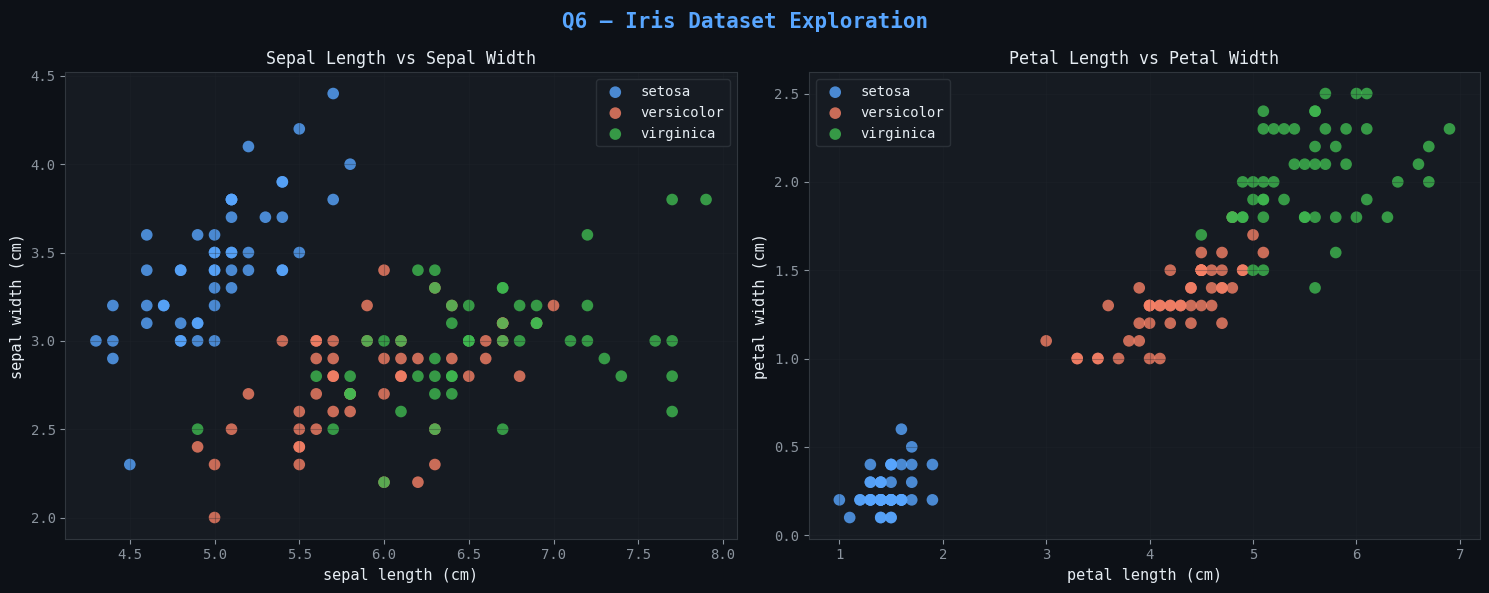

In [6]:
# Q6: Exploratory Visualisation
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Q6 – Iris Dataset Exploration', fontsize=15, color='#58a6ff', fontweight='bold')

pair_features = [(0, 1), (2, 3)]
titles = ['Sepal Length vs Sepal Width', 'Petal Length vs Petal Width']
cls_colors = [COLORS[0], COLORS[1], COLORS[2]]

for ax, (f1, f2), title in zip(axes, pair_features, titles):
    for cls in range(3):
        mask = y == cls
        ax.scatter(X[mask, f1], X[mask, f2], c=cls_colors[cls],
                   s=70, alpha=0.8, label=target_names[cls], edgecolors='none')
    ax.set_xlabel(feature_names[f1], fontsize=11)
    ax.set_ylabel(feature_names[f2], fontsize=11)
    ax.set_title(title, fontsize=12, color='#e6edf3')
    ax.legend(facecolor='#161b22', edgecolor='#30363d')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('q6_iris_eda.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

In [7]:
# Q6: Train-Test Split, Scale, Train SVM with multiple kernels
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

kernels = ['linear', 'rbf', 'poly', 'sigmoid']
results = {}

print('\n' + '='*55)
print('      SVM KERNEL COMPARISON ON IRIS')
print('='*55)
print(f"{'Kernel':<12} {'Train Acc':>10} {'Test Acc':>10} {'# SVs':>8}")
print('-'*45)

for k in kernels:
    clf_k = SVC(kernel=k, C=1.0, gamma='scale', random_state=42)
    clf_k.fit(X_train_sc, y_train)
    tr_acc = accuracy_score(y_train, clf_k.predict(X_train_sc))
    te_acc = accuracy_score(y_test,  clf_k.predict(X_test_sc))
    n_sv   = len(clf_k.support_vectors_)
    results[k] = {'clf': clf_k, 'train_acc': tr_acc, 'test_acc': te_acc, 'n_sv': n_sv}
    print(f"{k:<12} {tr_acc:>10.4f} {te_acc:>10.4f} {n_sv:>8}")

print('='*55)


      SVM KERNEL COMPARISON ON IRIS
Kernel        Train Acc   Test Acc    # SVs
---------------------------------------------
linear           0.9714     0.9111       21
rbf              0.9714     0.9333       40
poly             0.9143     0.8667       39
sigmoid          0.9143     0.9111       42



 Classification Report (RBF Kernel):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.88      0.93      0.90        15
   virginica       0.93      0.87      0.90        15

    accuracy                           0.93        45
   macro avg       0.93      0.93      0.93        45
weighted avg       0.93      0.93      0.93        45



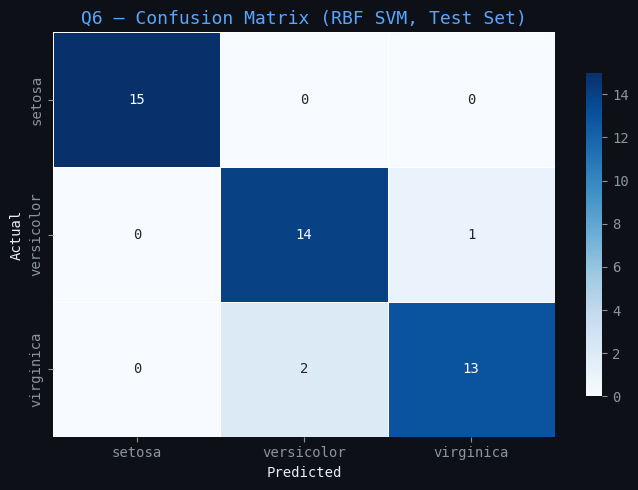

In [8]:
# Q6: Detailed report for best kernel (RBF)
best_clf = results['rbf']['clf']
y_pred = best_clf.predict(X_test_sc)

print('\n Classification Report (RBF Kernel):')
print(classification_report(y_test, y_pred, target_names=target_names))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names,
            ax=ax, linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Q6 – Confusion Matrix (RBF SVM, Test Set)', color='#58a6ff', fontsize=13)
ax.set_xlabel('Predicted', color='#e6edf3')
ax.set_ylabel('Actual', color='#e6edf3')
plt.tight_layout()
plt.savefig('q6_confusion_matrix.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

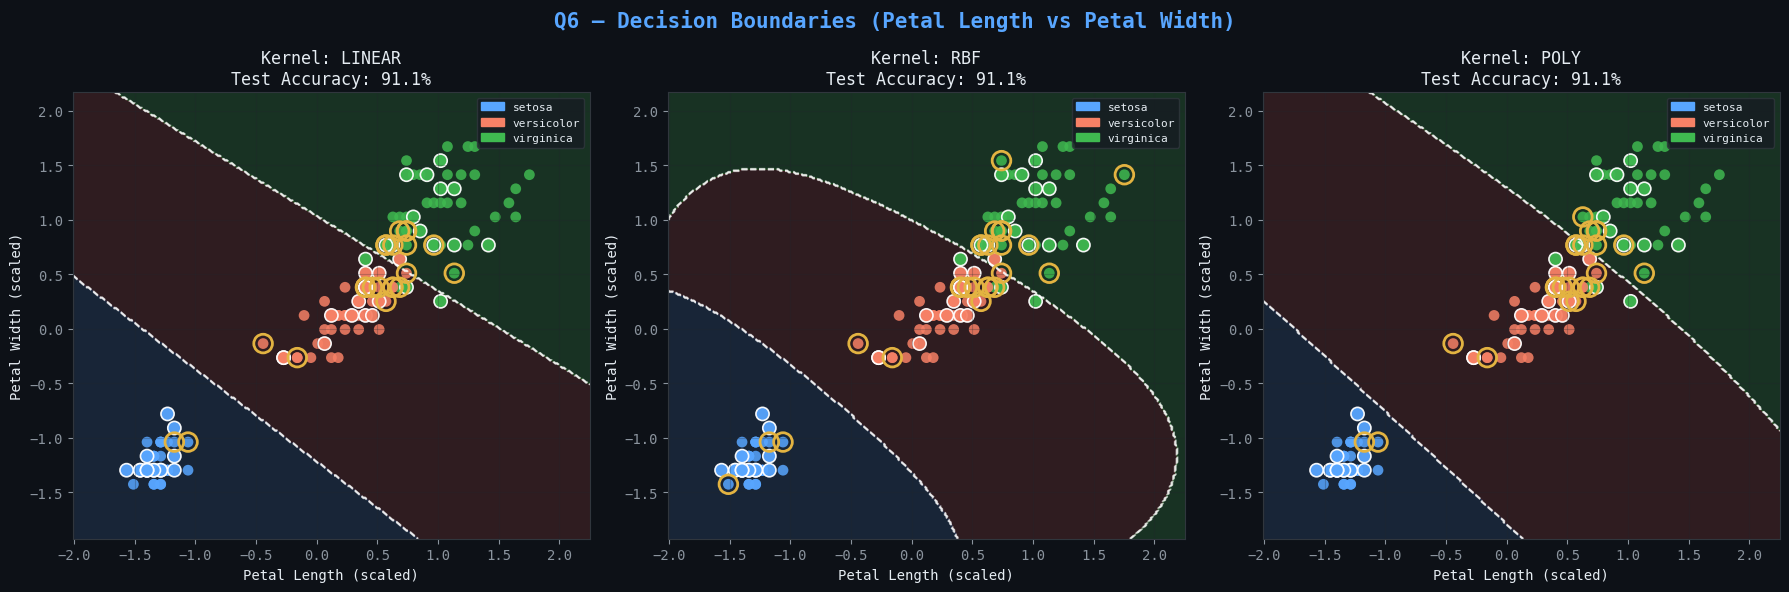

✅ Q6 Decision boundaries plotted!


In [9]:
# Q6: Decision Boundaries using 2 features (Petal L & W)
X2 = X[:, 2:4]  # petal length & petal width
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y, test_size=0.3, random_state=42, stratify=y)

sc2 = StandardScaler()
X2_train_sc = sc2.fit_transform(X2_train)
X2_test_sc  = sc2.transform(X2_test)

kernels_2 = ['linear', 'rbf', 'poly']
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Q6 – Decision Boundaries (Petal Length vs Petal Width)',
             fontsize=15, color='#58a6ff', fontweight='bold')

cmap_bg = ListedColormap(['#1e3a5f', '#5f1e1e', '#1e5f25'])
cmap_pt = ListedColormap([COLORS[0], COLORS[1], COLORS[2]])

for ax, k in zip(axes, kernels_2):
    c = SVC(kernel=k, C=1.0, gamma='scale', random_state=42)
    c.fit(X2_train_sc, y2_train)
    acc = accuracy_score(y2_test, c.predict(X2_test_sc))

    x_min, x_max = X2_train_sc[:, 0].min() - 0.5, X2_train_sc[:, 0].max() + 0.5
    y_min, y_max = X2_train_sc[:, 1].min() - 0.5, X2_train_sc[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    Z = c.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.35, cmap=cmap_bg)
    ax.contour(xx, yy, Z, colors='white', linewidths=1.2, linestyles='--', alpha=0.5)
    scatter = ax.scatter(X2_train_sc[:, 0], X2_train_sc[:, 1],
                         c=y2_train, cmap=cmap_pt, s=60, alpha=0.85, edgecolors='none', label='Train')
    ax.scatter(X2_test_sc[:, 0], X2_test_sc[:, 1],
               c=y2_test, cmap=cmap_pt, s=90, alpha=0.95, edgecolors='white', linewidths=1.2, label='Test')
    ax.scatter(c.support_vectors_[:, 0], c.support_vectors_[:, 1],
               s=180, facecolors='none', edgecolors='#e3b341', lw=2, zorder=5)
    ax.set_title(f'Kernel: {k.upper()}\nTest Accuracy: {acc:.1%}', fontsize=12, color='#e6edf3')
    ax.set_xlabel('Petal Length (scaled)'); ax.set_ylabel('Petal Width (scaled)')
    ax.grid(True, alpha=0.25)
    patches = [mpatches.Patch(color=COLORS[i], label=target_names[i]) for i in range(3)]
    ax.legend(handles=patches, fontsize=8, facecolor='#161b22', edgecolor='#30363d')

plt.tight_layout()
plt.savefig('q6_decision_boundaries.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('✅ Q6 Decision boundaries plotted!')

---
## 🏆 BONUS TASK: Linear SVM from Scratch vs Scikit-learn
---

In [11]:
# BONUS: Linear SVM from scratch using Sub-Gradient Descent

class LinearSVMScratch:
    """
    Linear SVM implemented from scratch using
    Stochastic Sub-Gradient Descent (Pegasos algorithm).

    Minimises:  (1/2)||w||^2 + C * sum(max(0, 1 - y_i*(w·x_i + b)))
    """
    def __init__(self, C=1.0, lr=0.001, n_epochs=1000, random_state=42):
        self.C = C
        self.lr = lr
        self.n_epochs = n_epochs
        self.random_state = random_state
        self.w = None
        self.b = None
        self.losses = []

    def _hinge_loss(self, X, y):
        margins = y * (X @ self.w + self.b)
        hinge = np.maximum(0, 1 - margins)
        return 0.5 * np.dot(self.w, self.w) + self.C * np.sum(hinge)

    def fit(self, X, y):
        """Labels must be -1 or +1."""
        np.random.seed(self.random_state)
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0.0
        self.losses = []

        for epoch in range(self.n_epochs):
            # Shuffle
            idx = np.random.permutation(n_samples)
            X_s, y_s = X[idx], y[idx]

            for xi, yi in zip(X_s, y_s):
                condition = yi * (np.dot(xi, self.w) + self.b)
                if condition < 1:
                    # Misclassified or inside margin
                    self.w -= self.lr * (self.w - self.C * yi * xi)
                    self.b -= self.lr * (-self.C * yi)
                else:
                    # Correct outside margin
                    self.w -= self.lr * self.w

            if epoch % 50 == 0:
                loss = self._hinge_loss(X, y)
                self.losses.append(loss)

        return self

    def predict(self, X):
        return np.sign(X @ self.w + self.b)

    def score(self, X, y):
        return np.mean(self.predict(X) == y)

print('✅ LinearSVMScratch class defined!')
print('   Algorithm: Sub-Gradient Descent (Pegasos)')
print('   Loss: Hinge Loss + L2 Regularisation')

✅ LinearSVMScratch class defined!
   Algorithm: Sub-Gradient Descent (Pegasos)
   Loss: Hinge Loss + L2 Regularisation


In [12]:
# BONUS: Binary classification (Iris: class 0 vs class 1)
# Use 2 classes for binary comparison
mask_binary = y != 2
X_bin = X[mask_binary]
y_bin = y[mask_binary]
y_bin_pm = np.where(y_bin == 0, -1, 1)  # Convert to ±1

X_bin_tr, X_bin_te, y_bin_tr, y_bin_te = train_test_split(
    X_bin, y_bin_pm, test_size=0.3, random_state=42
)
sc_bin = StandardScaler()
X_bin_tr_sc = sc_bin.fit_transform(X_bin_tr)
X_bin_te_sc = sc_bin.transform(X_bin_te)

# Train from-scratch SVM
svm_scratch = LinearSVMScratch(C=1.0, lr=0.001, n_epochs=500)
svm_scratch.fit(X_bin_tr_sc, y_bin_tr)
scratch_acc = svm_scratch.score(X_bin_te_sc, y_bin_te)

# Train scikit-learn SVM
svm_sklearn = SVC(kernel='linear', C=1.0)
svm_sklearn.fit(X_bin_tr_sc, y_bin_tr)
y_sk_pred = svm_sklearn.predict(X_bin_te_sc)
sklearn_acc = accuracy_score(y_bin_te, y_sk_pred)

print('\n' + '='*55)
print('   FROM SCRATCH vs SCIKIT-LEARN COMPARISON')
print('='*55)
print(f'   From Scratch Accuracy : {scratch_acc:.4f} ({scratch_acc*100:.2f}%)')
print(f'   Scikit-learn Accuracy : {sklearn_acc:.4f} ({sklearn_acc*100:.2f}%)')
print(f'   Difference            : {abs(scratch_acc - sklearn_acc):.4f}')
print('='*55)


   FROM SCRATCH vs SCIKIT-LEARN COMPARISON
   From Scratch Accuracy : 1.0000 (100.00%)
   Scikit-learn Accuracy : 1.0000 (100.00%)
   Difference            : 0.0000


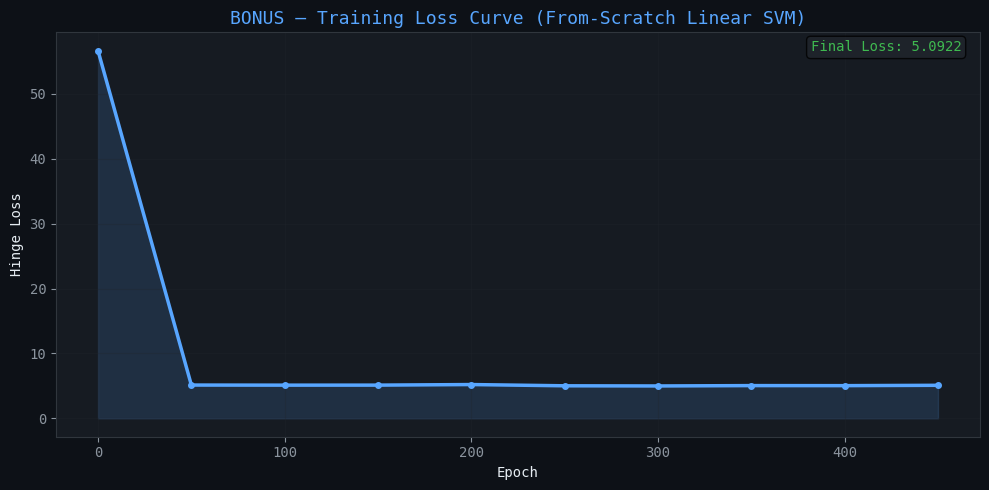

In [13]:
# BONUS: Plot Loss Curve
fig, ax = plt.subplots(figsize=(10, 5))
epochs_logged = list(range(0, svm_scratch.n_epochs, 50))
ax.plot(epochs_logged, svm_scratch.losses, color=COLORS[0], lw=2.5, marker='o', markersize=4)
ax.fill_between(epochs_logged, svm_scratch.losses, alpha=0.15, color=COLORS[0])
ax.set_title('BONUS – Training Loss Curve (From-Scratch Linear SVM)', fontsize=13, color='#58a6ff')
ax.set_xlabel('Epoch'); ax.set_ylabel('Hinge Loss')
ax.grid(True, alpha=0.3)
ax.text(0.98, 0.98, f'Final Loss: {svm_scratch.losses[-1]:.4f}',
        transform=ax.transAxes, ha='right', va='top', color='#3fb950', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='#21262d', alpha=0.8))
plt.tight_layout()
plt.savefig('bonus_loss_curve.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

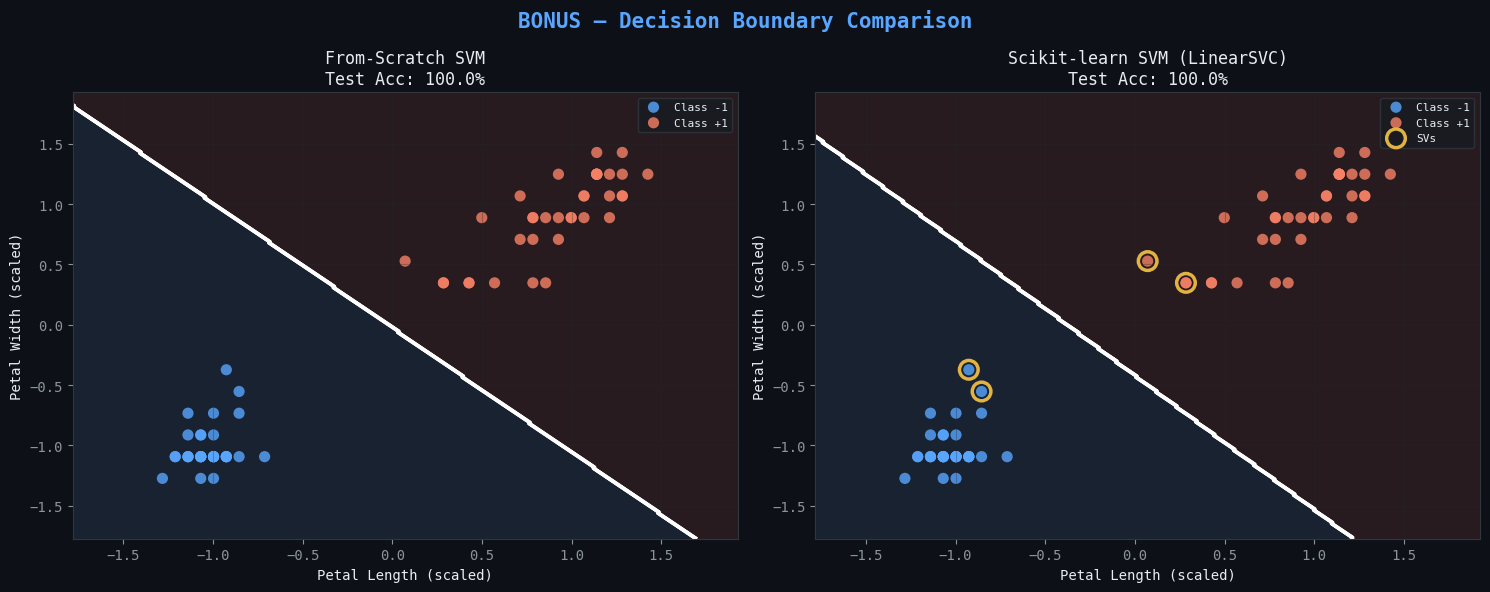

In [14]:
# BONUS: Plot decision boundaries comparison (2 features)
X_bin2 = X_bin[:, 2:4]  # petal features
X_b2_tr, X_b2_te, y_b2_tr, y_b2_te = train_test_split(
    X_bin2, y_bin_pm, test_size=0.3, random_state=42
)
sc_b2 = StandardScaler()
X_b2_tr_sc = sc_b2.fit_transform(X_b2_tr)
X_b2_te_sc = sc_b2.transform(X_b2_te)

svm_s2 = LinearSVMScratch(C=1.0, lr=0.001, n_epochs=1000)
svm_s2.fit(X_b2_tr_sc, y_b2_tr)

svm_sk2 = SVC(kernel='linear', C=1.0)
svm_sk2.fit(X_b2_tr_sc, y_b2_tr)

def plot_boundary_scratch(ax, model, X_tr, y_tr, title, is_scratch=True):
    x_min, x_max = X_tr[:, 0].min() - 0.5, X_tr[:, 0].max() + 0.5
    y_min, y_max = X_tr[:, 1].min() - 0.5, X_tr[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap=ListedColormap(['#1e3a5f', '#5f1e1e']))
    ax.contour(xx, yy, Z, colors='white', linewidths=2, linestyles='-')
    for cls, col, label in zip([-1, 1], [COLORS[0], COLORS[1]], ['Class -1', 'Class +1']):
        mask = y_tr == cls
        ax.scatter(X_tr[mask, 0], X_tr[mask, 1], c=col, s=65, alpha=0.8, label=label, edgecolors='none')
    if not is_scratch:
        ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1],
                   s=180, facecolors='none', edgecolors='#e3b341', lw=2.5, zorder=6, label='SVs')
    acc = model.score(X_b2_te_sc, y_b2_te)
    ax.set_title(f'{title}\nTest Acc: {acc:.1%}', fontsize=12, color='#e6edf3')
    ax.set_xlabel('Petal Length (scaled)'); ax.set_ylabel('Petal Width (scaled)')
    ax.legend(fontsize=8, facecolor='#161b22', edgecolor='#30363d')
    ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('BONUS – Decision Boundary Comparison', fontsize=15, color='#58a6ff', fontweight='bold')
plot_boundary_scratch(axes[0], svm_s2, X_b2_tr_sc, y_b2_tr, 'From-Scratch SVM', is_scratch=True)
plot_boundary_scratch(axes[1], svm_sk2, X_b2_tr_sc, y_b2_tr, 'Scikit-learn SVM (LinearSVC)', is_scratch=False)
plt.tight_layout()
plt.savefig('bonus_boundary_compare.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

In [15]:
# BONUS: Effect of Regularisation Parameter C
C_values = [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]

# Full 3-class iris
X_c = X; y_c = y
X_c_tr, X_c_te, y_c_tr, y_c_te = train_test_split(X_c, y_c, test_size=0.3, random_state=42, stratify=y_c)
sc_c = StandardScaler()
X_c_tr_sc = sc_c.fit_transform(X_c_tr)
X_c_te_sc  = sc_c.transform(X_c_te)

train_accs, test_accs, n_svs = [], [], []

print(f"{'C':>8} {'Train Acc':>12} {'Test Acc':>12} {'Num SVs':>10}")
print('-' * 48)

for C in C_values:
    clf_c = SVC(kernel='rbf', C=C, gamma='scale', random_state=42)
    clf_c.fit(X_c_tr_sc, y_c_tr)
    tr_a = accuracy_score(y_c_tr, clf_c.predict(X_c_tr_sc))
    te_a = accuracy_score(y_c_te, clf_c.predict(X_c_te_sc))
    nsv  = len(clf_c.support_vectors_)
    train_accs.append(tr_a); test_accs.append(te_a); n_svs.append(nsv)
    print(f"{C:>8.3f} {tr_a:>12.4f} {te_a:>12.4f} {nsv:>10}")

print()
best_C = C_values[np.argmax(test_accs)]
print(f'➜ Best C by test accuracy: {best_C}')

       C    Train Acc     Test Acc    Num SVs
------------------------------------------------
   0.001       0.8857       0.8667        105
   0.010       0.8857       0.8667        105
   0.100       0.8952       0.8667         87
   0.500       0.9810       0.9111         51
   1.000       0.9714       0.9333         40
   5.000       0.9810       0.9333         29
  10.000       0.9810       0.9333         27
  50.000       0.9905       0.9556         22
 100.000       1.0000       0.9333         20

➜ Best C by test accuracy: 50.0


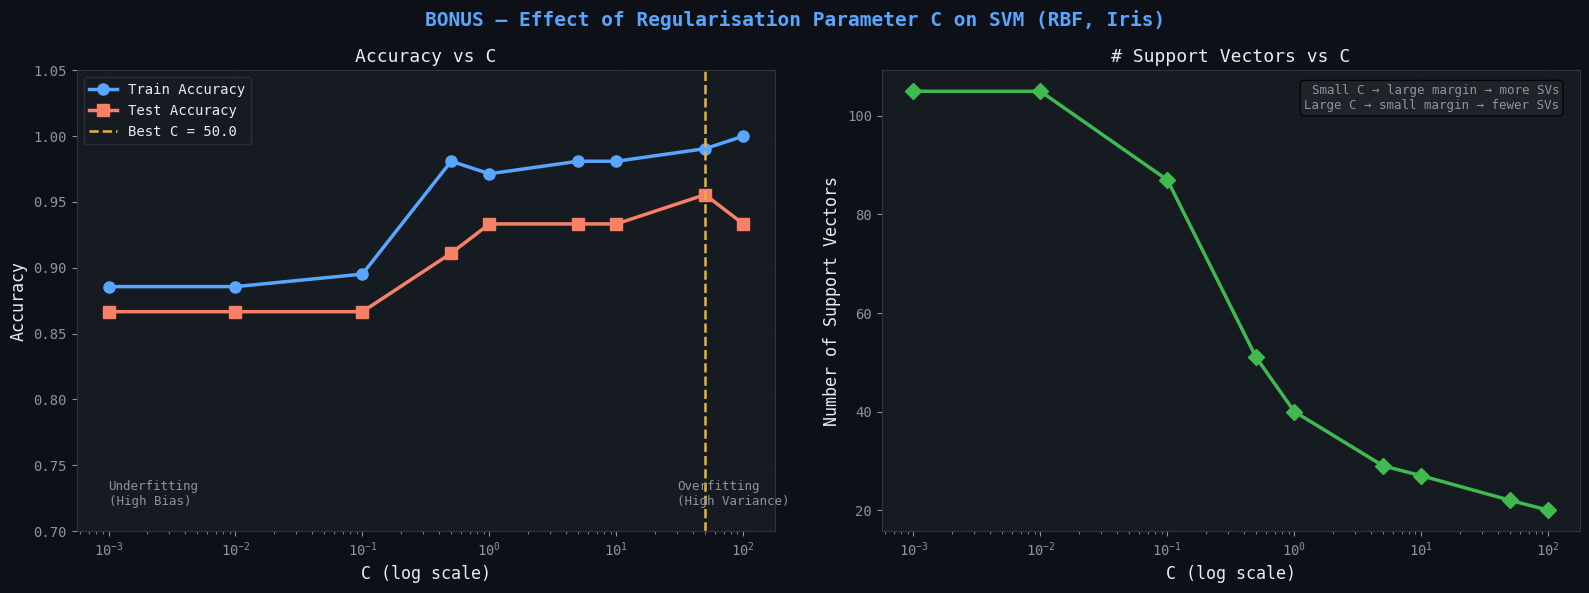

✅ C parameter analysis complete!


In [16]:
# BONUS: Plot Effect of C
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('BONUS – Effect of Regularisation Parameter C on SVM (RBF, Iris)',
             fontsize=14, color='#58a6ff', fontweight='bold')

ax1, ax2 = axes

# Accuracy vs C
ax1.plot(C_values, train_accs, 'o-', color=COLORS[0], lw=2.5, markersize=8, label='Train Accuracy')
ax1.plot(C_values, test_accs, 's-', color=COLORS[1], lw=2.5, markersize=8, label='Test Accuracy')
ax1.axvline(best_C, color='#e3b341', lw=1.8, linestyle='--', label=f'Best C = {best_C}')
ax1.set_xscale('log')
ax1.set_xlabel('C (log scale)', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Accuracy vs C', fontsize=13, color='#e6edf3')
ax1.legend(facecolor='#161b22', edgecolor='#30363d')
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0.7, 1.05])

# Explanation annotations
ax1.annotate('Underfitting\n(High Bias)', xy=(0.001, 0.72), color='#8b949e', fontsize=9)
ax1.annotate('Overfitting\n(High Variance)', xy=(30, 0.72), color='#8b949e', fontsize=9)

# Support Vectors vs C
ax2.plot(C_values, n_svs, 'D-', color=COLORS[2], lw=2.5, markersize=8)
ax2.set_xscale('log')
ax2.set_xlabel('C (log scale)', fontsize=12)
ax2.set_ylabel('Number of Support Vectors', fontsize=12)
ax2.set_title('# Support Vectors vs C', fontsize=13, color='#e6edf3')
ax2.grid(True, alpha=0.3)

text = ('Small C → large margin → more SVs\n'
        'Large C → small margin → fewer SVs')
ax2.text(0.97, 0.97, text, transform=ax2.transAxes, ha='right', va='top',
         color='#8b949e', fontsize=9, bbox=dict(boxstyle='round', facecolor='#21262d', alpha=0.85))

plt.tight_layout()
plt.savefig('bonus_c_analysis.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('✅ C parameter analysis complete!')

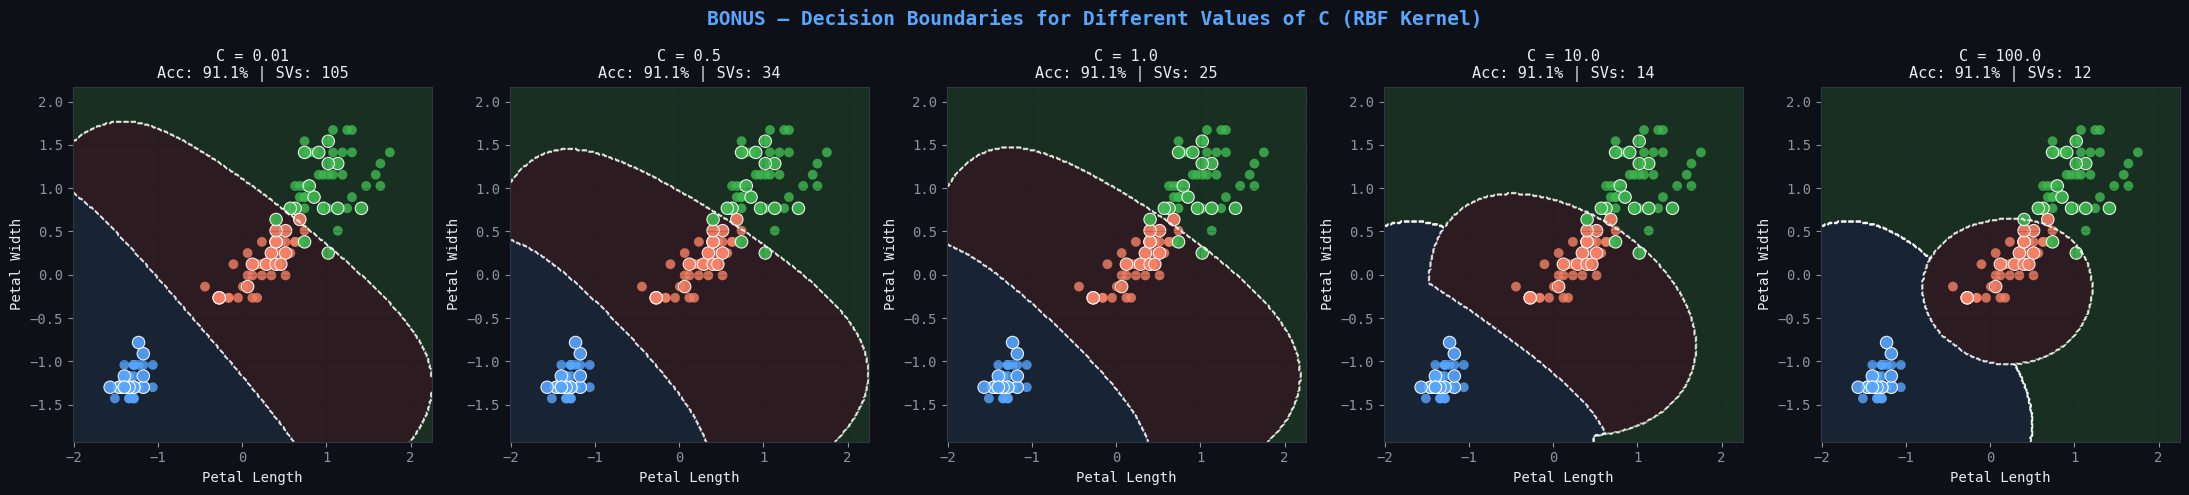

In [17]:
# BONUS: Decision boundaries for different C values
X_vis = X[:, 2:4]  # petal features
y_vis = y
X_vis_tr, X_vis_te, y_vis_tr, y_vis_te = train_test_split(X_vis, y_vis, test_size=0.3,
                                                            random_state=42, stratify=y_vis)
sc_vis = StandardScaler()
X_vis_tr_sc = sc_vis.fit_transform(X_vis_tr)
X_vis_te_sc = sc_vis.transform(X_vis_te)

C_show = [0.01, 0.5, 1.0, 10.0, 100.0]
fig, axes = plt.subplots(1, len(C_show), figsize=(22, 5))
fig.suptitle('BONUS – Decision Boundaries for Different Values of C (RBF Kernel)',
             fontsize=14, color='#58a6ff', fontweight='bold')

cmap_3bg = ListedColormap(['#1e3a5f', '#5f1e1e', '#1e5f25'])
cmap_3pt = ListedColormap([COLORS[0], COLORS[1], COLORS[2]])

for ax, C in zip(axes, C_show):
    clf = SVC(kernel='rbf', C=C, gamma='scale', random_state=42)
    clf.fit(X_vis_tr_sc, y_vis_tr)

    x_min, x_max = X_vis_tr_sc[:,0].min()-0.5, X_vis_tr_sc[:,0].max()+0.5
    y_min, y_max = X_vis_tr_sc[:,1].min()-0.5, X_vis_tr_sc[:,1].max()+0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 250), np.linspace(y_min, y_max, 250))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_3bg)
    ax.contour(xx, yy, Z, colors='white', linewidths=1, linestyles='--', alpha=0.5)
    ax.scatter(X_vis_tr_sc[:,0], X_vis_tr_sc[:,1], c=y_vis_tr,
               cmap=cmap_3pt, s=50, alpha=0.8, edgecolors='none')
    ax.scatter(X_vis_te_sc[:,0], X_vis_te_sc[:,1], c=y_vis_te,
               cmap=cmap_3pt, s=80, alpha=0.9, edgecolors='white', linewidths=0.8)

    te_acc = accuracy_score(y_vis_te, clf.predict(X_vis_te_sc))
    nsv = len(clf.support_vectors_)
    ax.set_title(f'C = {C}\nAcc: {te_acc:.1%} | SVs: {nsv}',
                 fontsize=11, color='#e6edf3')
    ax.set_xlabel('Petal Length')
    ax.set_ylabel('Petal Width')
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('bonus_c_decision_boundaries.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()